# Examen Aplicado de Machine Learning I

## Dataset: Bike Sharing

- **Fuente:** UCI Machine Learning Repository
- **URL:** https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
- **Archivo utilizado:** day.csv
- **Número de filas:** 731
- **Número de columnas:** 16
- **Variable objetivo:** `cnt`
- **Tipo de tarea:** Regresión


In [1]:
# Bibliotecas 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el archivo CSV en un DataFrame
df = pd.read_csv("day.csv")

# Mostrar las dimensiones del dataset
df.shape

(731, 16)

In [3]:
# Mostrar el tipo de dato de cada columna
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [4]:
# Mostrar información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [5]:
# Mostrar estadísticas descriptivas de las variables numéricas
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
# Mostrar las primeras 5 filas del dataset
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Interpretación de la inspección inicial

El dataset contiene 731 observaciones diarias y 16 columnas. La variable `dteday` fue cargada como texto, mientras que las variables `temp`, `atemp`, `hum` y `windspeed` son numéricas continuas. Varias variables categóricas, como `season`, `mnth`, `weekday` y `weathersit`, se encuentran representadas mediante códigos numéricos.

Todas las columnas presentan 731 valores no nulos, por lo que inicialmente no se observan datos faltantes. La columna `instant` corresponde a un identificador del registro. Además, se comprobó que `cnt` es la suma de `casual` y `registered`; por esta razón, estas dos variables no deberán utilizarse como predictoras, ya que producirían fuga de información.

## Análisis de valores faltantes

In [7]:
# Calcular la cantidad de valores nulos por columna
cantidad_nulos = df.isnull().sum()

# Calcular el porcentaje de valores nulos por columna
porcentaje_nulos = (cantidad_nulos / len(df)) * 100

# Organizar los resultados en una tabla
resumen_nulos = pd.DataFrame({
    "Cantidad de nulos": cantidad_nulos,
    "Porcentaje de nulos (%)": porcentaje_nulos.round(2)
})

resumen_nulos

,Cantidad de nulos,Porcentaje de nulos (%)
instant,0,0.0
dteday,0,0.0
season,0,0.0
yr,0,0.0
mnth,0,0.0
holiday,0,0.0
weekday,0,0.0
workingday,0,0.0
weathersit,0,0.0
temp,0,0.0


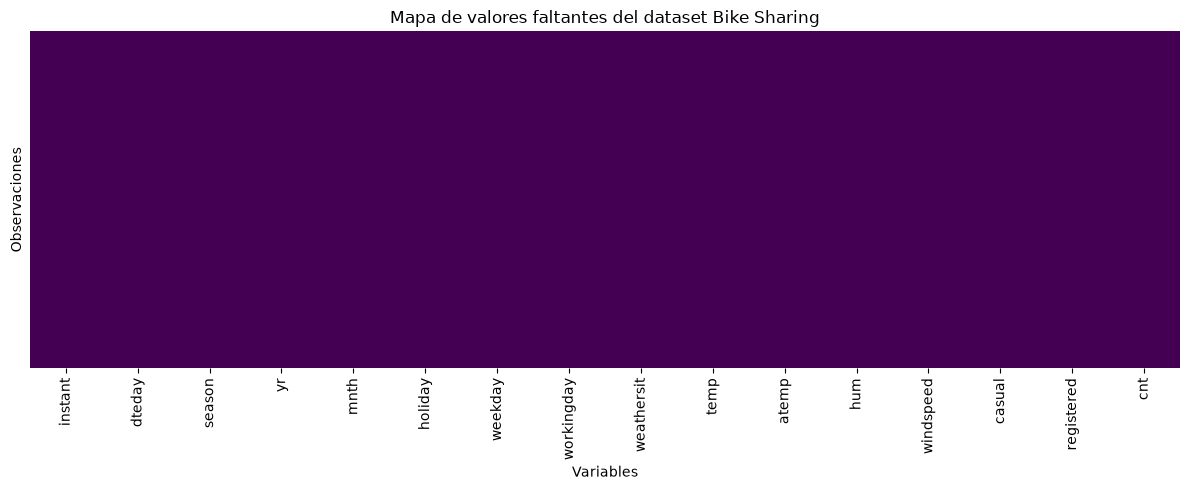

In [8]:
# Crear un mapa de calor de los valores faltantes
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Mapa de valores faltantes del dataset Bike Sharing")
plt.xlabel("Variables")
plt.ylabel("Observaciones")
plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/heatmap_valores_faltantes.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de los valores faltantes

El análisis confirmó que las 16 columnas contienen 731 valores válidos, equivalentes al 100% de las observaciones. Por lo tanto, el porcentaje de valores nulos es 0,0% en todas las variables. El heatmap presenta un color uniforme, lo que confirma visualmente la ausencia de datos faltantes.

Debido a que el dataset está completo, no se eliminarán columnas ni se aplicará imputación en esta etapa. Sin embargo, el pipeline de preprocesamiento incorporará `SimpleImputer`, tal como piden las instrucciones del examen, y será ajustado exclusivamente con los datos de entrenamiento para evitar fuga de información.

## Detección y tratamiento de outliers

In [9]:
# Variables numéricas continuas que serán utilizadas como predictoras
variables_continuas = ["temp", "atemp", "hum", "windspeed"]

# Calcular el primer y tercer cuartil
Q1 = df[variables_continuas].quantile(0.25)
Q3 = df[variables_continuas].quantile(0.75)

# Calcular el rango intercuartílico
IQR = Q3 - Q1

# Definir los límites para detectar posibles outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar los valores que están fuera de los límites
mascara_outliers = (
    (df[variables_continuas] < limite_inferior) |
    (df[variables_continuas] > limite_superior)
)

# Contar y calcular el porcentaje de outliers por variable
cantidad_outliers = mascara_outliers.sum()
porcentaje_outliers = (cantidad_outliers / len(df)) * 100

# Organizar los resultados en una tabla
resumen_outliers = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Límite inferior": limite_inferior,
    "Límite superior": limite_superior,
    "Cantidad de outliers": cantidad_outliers,
    "Porcentaje de outliers (%)": porcentaje_outliers
})

resumen_outliers.round(4)

,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers (%)
temp,0.3371,0.6554,0.3183,-0.1404,1.1329,0,0.0000
atemp,0.3378,0.6086,0.2708,-0.0683,1.0147,0,0.0000
hum,0.5200,0.7302,0.2102,0.2047,1.0455,2,0.2736
windspeed,0.1349,0.2332,0.0983,-0.0124,0.3806,13,1.7784


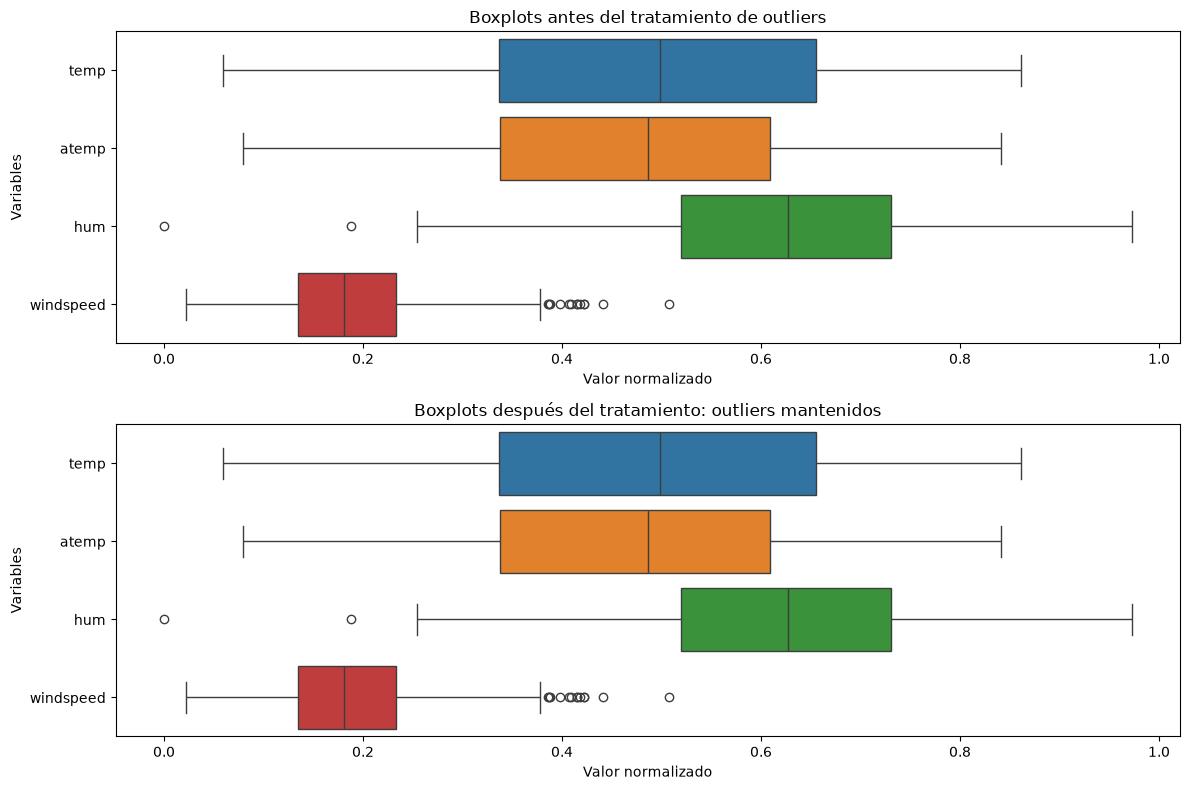

In [10]:
# Mantener los outliers porque corresponden a condiciones meteorológicas posibles
df_tratado = df.copy()

# Crear boxplots antes y después de la decisión de tratamiento
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.boxplot(
    data=df[variables_continuas],
    orient="h",
    ax=axes[0]
)
axes[0].set_title("Boxplots antes del tratamiento de outliers")
axes[0].set_xlabel("Valor normalizado")
axes[0].set_ylabel("Variables")

sns.boxplot(
    data=df_tratado[variables_continuas],
    orient="h",
    ax=axes[1]
)
axes[1].set_title("Boxplots después del tratamiento: outliers mantenidos")
axes[1].set_xlabel("Valor normalizado")
axes[1].set_ylabel("Variables")

plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/boxplots_outliers_antes_despues.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación y decisión sobre los valores extremos

El método IQR no identificó valores extremos en las variables `temp` y `atemp`. En cambio, detectó 2 valores extremos en `hum`, equivalentes al 0,2736% de las observaciones, y 13 en `windspeed`, correspondientes al 1,7784%.

Se decidió mantener estos valores porque representan condiciones meteorológicas reales que pueden ocurrir en determinados días. Un nivel inusual de humedad o una velocidad elevada del viento no constituye necesariamente un error de registro y podría aportar información relevante para explicar cambios en la demanda de bicicletas. Además, la proporción de valores extremos es baja y no existe evidencia que justifique su eliminación o imputación. 



## Distribución de la variable objetivo

Skewness de cnt: -0.0474


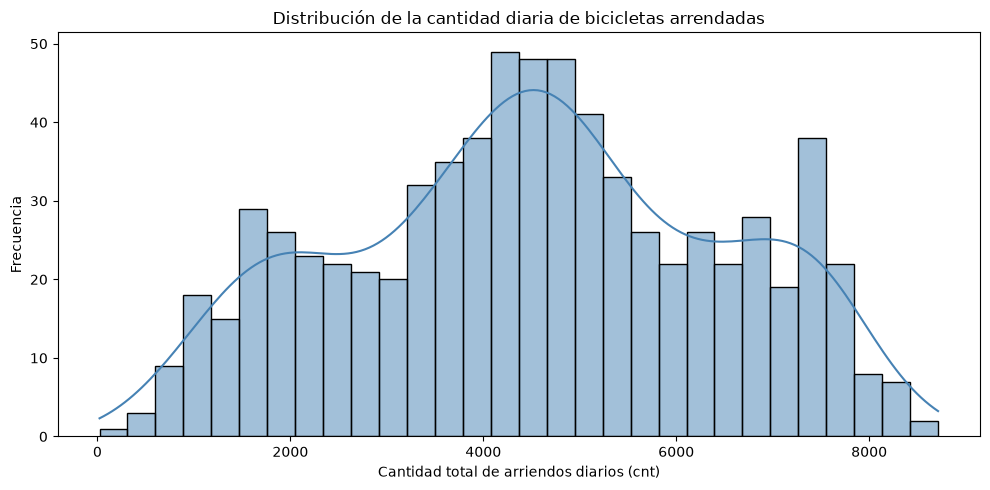

In [11]:
# Calcular la asimetría de la variable objetivo
asimetria_cnt = df["cnt"].skew()

print(f"Skewness de cnt: {asimetria_cnt:.4f}")

# Crear el histograma junto con la curva KDE
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="cnt",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribución de la cantidad diaria de bicicletas arrendadas")
plt.xlabel("Cantidad total de arriendos diarios (cnt)")
plt.ylabel("Frecuencia")
plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/distribucion_variable_objetivo_cnt.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de la variable objetivo

La variable objetivo `cnt` presenta un skewness de -0,0474, valor muy cercano a cero. Esto indica que su distribución es aproximadamente simétrica, con una inclinación negativa mínima. Aunque la curva KDE muestra algunas concentraciones en distintos niveles de demanda, no se observa una asimetría pronunciada.

Como el valor de skewness no supera el límite de 1,0 establecido en la guía, no se aplicará una transformación logarítmica. La variable objetivo se mantendrá en su escala original, lo que también facilitará la interpretación posterior de las predicciones y de las métricas de error en términos de cantidad diaria de bicicletas arrendadas.

## Análisis exploratorio y correlaciones

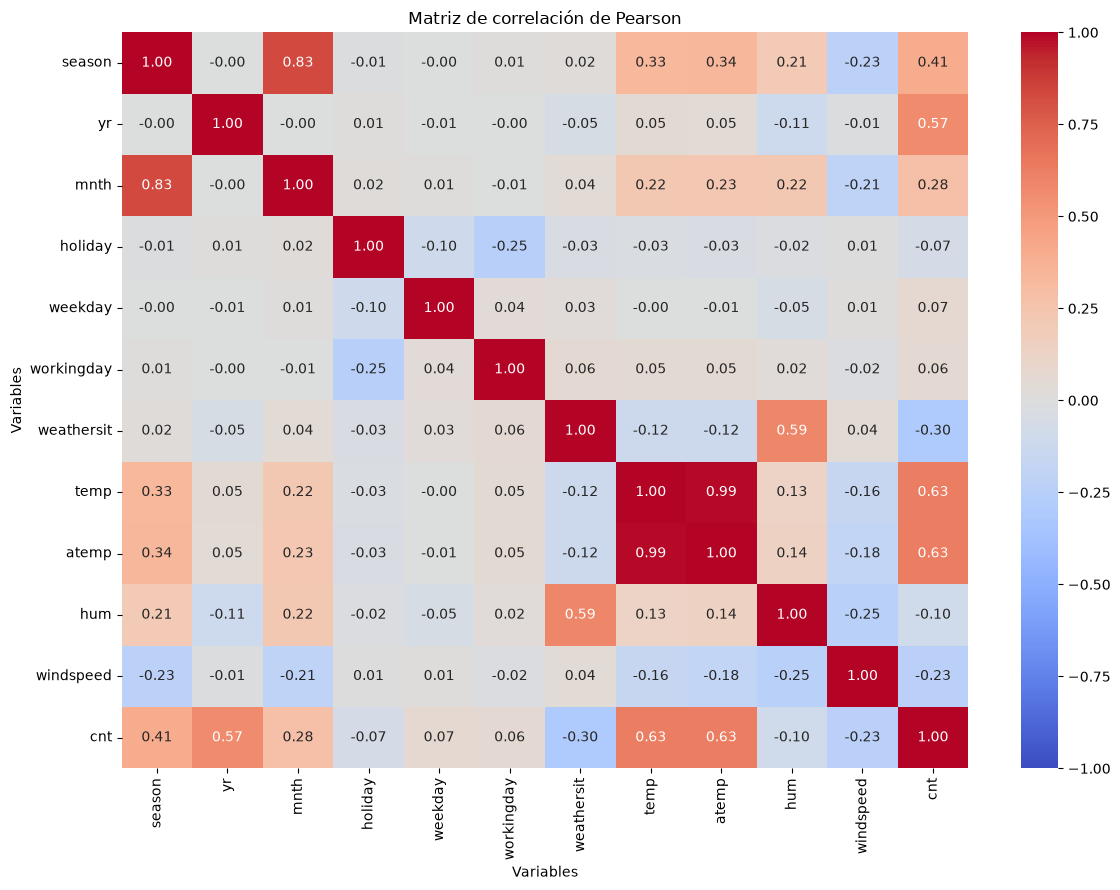

In [12]:
# Crear un DataFrame para el EDA sin identificadores ni variables con fuga de información
df_eda = df.drop(
    columns=["instant", "dteday", "casual", "registered"]
)

# Calcular la matriz de correlación de Pearson
matriz_correlacion = df_eda.corr(method="pearson")

# Crear el heatmap de correlaciones
plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación de Pearson")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/heatmap_correlacion_pearson.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Obtener las correlaciones de todas las variables con la variable objetivo
correlaciones_objetivo = matriz_correlacion["cnt"].drop("cnt")

# Seleccionar las 5 correlaciones más altas en valor absoluto
indices_top5 = correlaciones_objetivo.abs().nlargest(5).index

# Crear una tabla con la correlación original y su valor absoluto
top5_correlaciones = pd.DataFrame({
    "Correlación con cnt": correlaciones_objetivo.loc[indices_top5],
    "Valor absoluto": correlaciones_objetivo.loc[indices_top5].abs()
})

top5_correlaciones.round(4)

,Correlación con cnt,Valor absoluto
atemp,0.6311,0.6311
temp,0.6275,0.6275
yr,0.5667,0.5667
season,0.4061,0.4061
weathersit,-0.2974,0.2974


In [14]:
# Crear la matriz de correlación solamente entre predictores
correlacion_predictores = df_eda.drop(columns="cnt").corr(method="pearson")

# Buscar pares de predictores con correlación absoluta superior a 0.85
pares_multicolineales = []

columnas_predictoras = correlacion_predictores.columns

for i in range(len(columnas_predictoras)):
    for j in range(i + 1, len(columnas_predictoras)):
        variable_1 = columnas_predictoras[i]
        variable_2 = columnas_predictoras[j]
        correlacion = correlacion_predictores.loc[variable_1, variable_2]

        if abs(correlacion) > 0.85:
            pares_multicolineales.append({
                "Variable 1": variable_1,
                "Variable 2": variable_2,
                "Correlación": correlacion
            })

tabla_multicolinealidad = pd.DataFrame(pares_multicolineales)

tabla_multicolinealidad.round(4)

,Variable 1,Variable 2,Correlación
0,temp,atemp,0.9917


### Interpretación de correlaciones y multicolinealidad

Las variables con mayor correlación absoluta con `cnt` fueron `atemp` (0,6311), `temp` (0,6275), `yr` (0,5667), `season` (0,4061) y `weathersit` (-0,2974). Las correlaciones positivas de `temp` y `atemp` indican que los días con temperaturas más elevadas tienden a presentar una mayor cantidad de arriendos. La correlación positiva de `yr` sugiere que la demanda fue mayor en el segundo año registrado.

Por otra parte, `weathersit` presenta una correlación negativa con `cnt`. Como sus valores aumentan cuando las condiciones meteorológicas empeoran, este resultado indica que el clima desfavorable se relaciona con una menor demanda de bicicletas. La correlación de `season` debe interpretarse con cautela, porque sus números representan categorías y no una escala cuantitativa continua.

El análisis de multicolinealidad identificó una correlación de 0,9917 entre `temp` y `atemp`, superior al límite de 0,85. Esto se explica porque ambas variables representan mediciones relacionadas con la temperatura. Se mantendrán inicialmente ambas variables, ya que solicitan reportar la multicolinealidad. Esta relación deberá considerarse posteriormente al interpretar los coeficientes y la importancia de variables.

### Relación de las variables más correlacionadas con la demanda

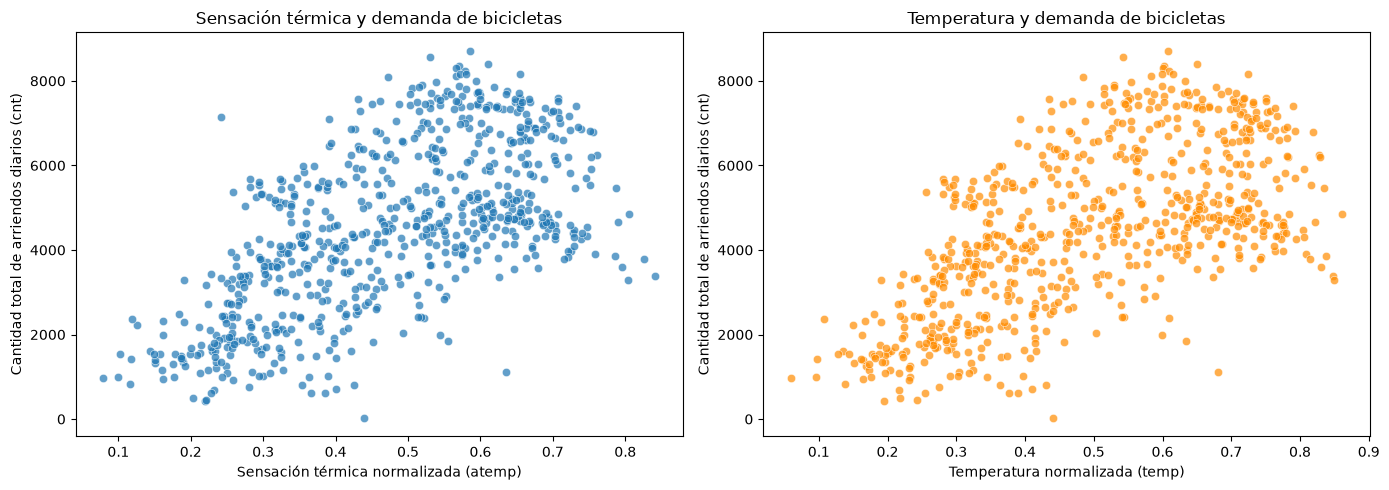

In [15]:
# Crear scatterplots de las dos variables más correlacionadas con cnt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_eda,
    x="atemp",
    y="cnt",
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Sensación térmica y demanda de bicicletas")
axes[0].set_xlabel("Sensación térmica normalizada (atemp)")
axes[0].set_ylabel("Cantidad total de arriendos diarios (cnt)")

sns.scatterplot(
    data=df_eda,
    x="temp",
    y="cnt",
    alpha=0.7,
    color="darkorange",
    ax=axes[1]
)
axes[1].set_title("Temperatura y demanda de bicicletas")
axes[1].set_xlabel("Temperatura normalizada (temp)")
axes[1].set_ylabel("Cantidad total de arriendos diarios (cnt)")

plt.tight_layout()

# Guardar la figura con la resolución exigida
plt.savefig(
    "figures/scatter_variables_mas_correlacionadas.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de los scatterplots

Los scatterplots muestran una relación positiva entre la demanda diaria de bicicletas y las variables `temp` y `atemp`. En general, los días con temperaturas y sensaciones térmicas más elevadas presentan una mayor cantidad de arriendos, lo que coincide con las correlaciones positivas de 0,6275 y 0,6311, respectivamente.

Sin embargo, los puntos presentan una dispersión considerable. Para valores similares de temperatura se observan cantidades diferentes de arriendos, lo que indica que la demanda no depende exclusivamente de esta condición meteorológica. Variables como el año, la estación, el tipo de día y las condiciones climáticas también podrían contribuir a explicar estas diferencias.

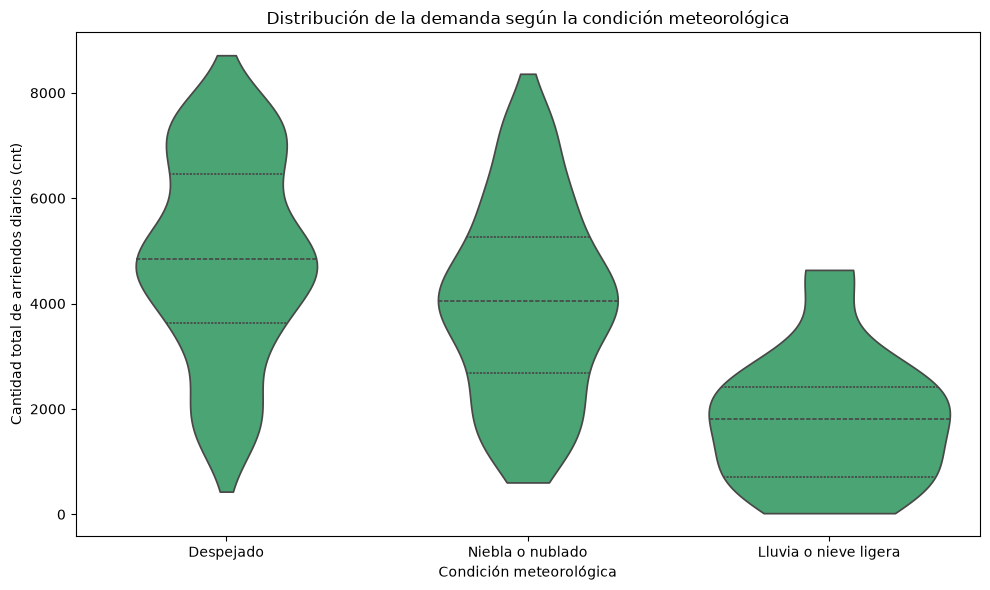

In [16]:
# Comparar la distribución de la demanda según la condición meteorológica
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_eda,
    x="weathersit",
    y="cnt",
    inner="quartile",
    cut=0,
    color="mediumseagreen"
)

plt.title("Distribución de la demanda según la condición meteorológica")
plt.xlabel("Condición meteorológica")
plt.ylabel("Cantidad total de arriendos diarios (cnt)")

plt.xticks(
    ticks=[0, 1, 2],
    labels=[
        "Despejado",
        "Niebla o nublado",
        "Lluvia o nieve ligera"
    ]
)

plt.tight_layout()

# Guardar la figura con la resolución exigida
plt.savefig(
    "figures/violin_demanda_condicion_meteorologica.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de la demanda según la condición meteorológica

El violin plot muestra diferencias en la distribución de la demanda según las condiciones meteorológicas. Los días despejados presentan la mediana más alta y una mayor concentración de observaciones en niveles elevados de arriendos. En los días con niebla o nubosidad, la mediana de `cnt` disminuye y la distribución se desplaza hacia valores intermedios.

Los días con lluvia o nieve ligera presentan la demanda más baja, con una mayor concentración de observaciones bajo los 3.000 arriendos diarios. Este patrón coincide con la correlación negativa de -0,2974 encontrada entre `weathersit` y `cnt`: a medida que las condiciones meteorológicas se vuelven más adversas, la cantidad de bicicletas arrendadas tiende a disminuir.